# YedroudjNet — Стеганоанализ LSB (V06)

---

## Архитектура модели YedroudjNetV06

### Общая идея

Модель решает задачу бинарной классификации: **cover** (оригинальное изображение) vs **stego** (изображение со скрытыми данными). Основная сложность — стеганографический сигнал крайне мал: изменения не превышают 1 единицы яркости на пиксель (≤ 1/255), что соответствует разнице в ~0.4% диапазона. Классические свёрточные сети, обученные на ImageNet, игнорируют такой сигнал — он полностью подавляется уже в первом слое. Поэтому YedroudjNet использует специализированный входной слой и иерархическую обработку.

---

### Блок 1 — Высокочастотный фильтр (HPF)

```
Вход: RGB-изображение [B, 3, 256, 256]
HPF:  Conv2d(3 → 30, kernel=5×5, padding=2, bias=False)
Активация: |tanh(·)|
Выход: [B, 30, 256, 256]
```

Первый слой — фиксированный **фильтр Кёнига** (King filter), инициализированный вручную и дообучаемый только в первые 5 эпох. Фильтр усиливает высокочастотные компоненты изображения, подавляя низкочастотный контент (общую яркость, цвет, текстуры крупного масштаба):

```
Ядро Кёнига (нормированное):
[-1  +2  -2  +2  -1]
[+2  -6  +8  -6  +2]
[-2  +8 -12  +8  -2]   / 96
[+2  -6  +8  -6  +2]
[-1  +2  -2  +2  -1]
```

Центральный коэффициент −12 максимально усиливает разницу между центральным пикселем и его окружением. После свёртки применяется `|tanh(·)|` — функция, которая:
- Ограничивает амплитуду выхода в диапазон [0, 1] через `tanh`
- Берёт модуль, делая ответ симметричным относительно знака отклонения

30 параллельных каналов позволяют выучить 30 различных проекций высокочастотного шума по трём RGB-каналам.

> **Почему это работает:** стеганографический сигнал (±1 в LSB) — высокочастотный шум. HPF подавляет всё остальное, оставляя именно его.

---

### Блоки 2–4 — Иерархическое извлечение признаков

Три последовательных блока `ConvBlock` с понижением разрешения:

| Блок | Вход | Выход | Разрешение |
|---|---|---|---|
| block1 + pool1 | 30 каналов | 64 канала | 256×256 → 128×128 |
| block2 + pool2 | 64 канала | 128 каналов | 128×128 → 64×64 |
| block3 | 128 каналов | 256 каналов | 64×64 (без пулинга) |

Каждый `ConvBlock` состоит из трёх операций в строгом порядке:

```
Conv2d(3×3, padding=1, bias=False)
    ↓
BatchNorm2d          ← нормализация до активации
    ↓
ReLU(inplace=True)   ← активация
    ↓
SEBlock              ← канальное перевзвешивание
```

**BatchNorm перед активацией** (а не после) — это важно: нормализация необработанных логитов стабилизирует обучение и предотвращает насыщение ReLU.

---

### SEBlock — Squeeze-and-Excitation

```python
x → GlobalAvgPool → FC(C → C//4) → ReLU → FC(C//4 → C) → Sigmoid → x * weight
```

SEBlock реализует **канальное самовнимание**: сеть учится, какие из 64/128/256 карт признаков наиболее информативны для текущего входа, и масштабирует их соответственно. Это особенно важно для стеганоанализа — не все частотные компоненты одинаково несут стего-сигнал.

Коэффициент сжатия `r=4`: скрытый слой содержит `max(C//4, 8)` нейронов — минимальный порог 8 предотвращает вырождение для малых C.

---

### Блок 5 — Классификационная голова

```
GlobalAvgPool2d(1)     → [B, 256, 1, 1]
Flatten                → [B, 256]
Dropout(p=0.5)         → регуляризация
Linear(256 → 1)        → логит
```

**Global Average Pooling** вместо Flatten — суммирует пространственную информацию по всей 64×64 карте признаков в один вектор из 256 чисел. Это уменьшает переобучение и делает модель инвариантной к позиции артефакта в изображении.

**Dropout(0.5)** — агрессивная регуляризация, критичная при небольшом датасете (2000 примеров). Отключает половину нейронов случайно на каждом шаге обучения.

**Linear(256 → 1)** — без sigmoid: сырой логит подаётся в `BCEWithLogitsLoss`, что численно стабильнее чем `sigmoid + BCELoss`.

---

### Стратегия обучения

| Параметр | Значение | Обоснование |
|---|---|---|
| Оптимизатор | Adam | адаптивный LR, быстрая сходимость |
| LR (основная сеть) | 3×10⁻⁴ | баланс скорости и стабильности |
| LR (HPF) | 3×10⁻⁵ | HPF обучается в 10× медленнее |
| Weight Decay | 1×10⁻⁴ | L2-регуляризация весов |
| Scheduler | CosineAnnealingLR | плавное снижение LR к концу |
| Loss | BCEWithLogitsLoss | численно стабильная бинарная кросс-энтропия |
| Grad clipping | max_norm=1.0 | предотвращает взрыв градиентов |
| Early stopping | patience=8 (по AUC) | останавливает фолд при стагнации |

**Двухфазное обучение HPF:**
- Эпохи 1–5: HPF разморожен (`requires_grad=True`), обучается с LR×0.1
- Эпохи 6+: HPF заморожен (`requires_grad=False`), веса фиксированы

Это позволяет HPF адаптироваться к конкретному типу стеганографии в первых эпохах, после чего он фиксируется как стабильный детектор шума.

**Аугментации (только train):**
- `RandomHorizontalFlip(p=0.5)` — зеркальное отражение по горизонтали
- `RandomVerticalFlip(p=0.5)` — зеркальное отражение по вертикали

> Намеренно *не используются*: ColorJitter, RandomRotation, RandomCrop — они изменяют пиксельные значения или геометрию, разрушая LSB-сигнал.

---

### Инициализация весов

| Слой | Инициализация |
|---|---|
| HPF (`hpf`) | вручную: фильтр Кёнига |
| Conv2d (остальные) | Kaiming Normal (mode='fan_out', nonlinearity='relu') |
| Linear | Xavier Uniform |
| BatchNorm | по умолчанию: weight=1, bias=0 |

Kaiming Normal оптимален для слоёв с ReLU-активацией — сохраняет дисперсию сигнала при прямом проходе. Xavier — для финального линейного слоя без нелинейности.

---

### Схема прямого прохода

```
Вход [B, 3, 256, 256]
         │
    ┌────▼────┐
    │   HPF   │  Conv(5×5) → |tanh(·)|
    └────┬────┘
         │ [B, 30, 256×256]
    ┌────▼──────┐
    │  ConvBlock│  Conv→BN→ReLU→SE
    │   block1  │
    └────┬──────┘
    ┌────▼────┐
    │ MaxPool │  2×2, stride=2
    └────┬────┘
         │ [B, 64, 128×128]
    ┌────▼──────┐
    │  ConvBlock│  Conv→BN→ReLU→SE
    │   block2  │
    └────┬──────┘
    ┌────▼────┐
    │ MaxPool │  2×2, stride=2
    └────┬────┘
         │ [B, 128, 64×64]
    ┌────▼──────┐
    │  ConvBlock│  Conv→BN→ReLU→SE
    │   block3  │
    └────┬──────┘
         │ [B, 256, 64×64]
    ┌────▼──────────┐
    │ GlobalAvgPool │  → [B, 256]
    └────┬──────────┘
    ┌────▼──────┐
    │ Dropout   │  p=0.5
    └────┬──────┘
    ┌────▼──────┐
    │  Linear   │  256 → 1  (логит)
    └────┬──────┘
         │
    Выход: P(stego) = sigmoid(логит)
```

---

### Валидация и оценка

Модель обучается по схеме **5-Fold Stratified Cross-Validation** исключительно на тренировочной выборке (X_train, 80% данных). Тестовая выборка (X_test, 20%) остаётся полностью изолированной до финальной оценки.

В каждом фолде сохраняется чекпоинт с наилучшим **ROC-AUC** на валидации. Оптимальный порог классификации вычисляется по критерию **Youden's J** (`max(TPR − FPR)`) на той же валидационной кривой ROC.

Финальная оценка производится лучшей из пяти моделей на изолированном holdout-тесте.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# 1. Импорт библиотек

import os, json, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, accuracy_score, precision_score, recall_score, f1_score
)


In [4]:
# Воспроизводимость

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')


Устройство: cuda


In [5]:
# 2. Конфигурация данных

COVER_DIR = '/content/drive/MyDrive/FQW/Stego-Images_clean6000/'
STEGO_DIR = '/content/drive/MyDrive/FQW/Stego-Images_stego6000/'
IMG_SIZE   = 256
MAX_IMAGES_PER_CLASS = 2000
SAVE_DIR   = '/content/drive/MyDrive/FQW/yedroudj_results_2000_v06'
os.makedirs(SAVE_DIR, exist_ok=True)

cover_imgs = sorted([os.path.join(COVER_DIR, f) for f in os.listdir(COVER_DIR)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))])[:MAX_IMAGES_PER_CLASS]
stego_imgs = sorted([os.path.join(STEGO_DIR, f) for f in os.listdir(STEGO_DIR)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))])[:MAX_IMAGES_PER_CLASS]

all_images = cover_imgs + stego_imgs
all_labels = [0] * len(cover_imgs) + [1] * len(stego_imgs)
print(f'Всего: Cover={len(cover_imgs)}, Stego={len(stego_imgs)}')

X_train, X_test, y_train, y_test = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=SEED, stratify=all_labels)

print(f'Train (для CV): {len(X_train)} | Holdout Test: {len(X_test)}')
print(f'Train balance: Cover={y_train.count(0)}, Stego={y_train.count(1)}')
print(f'Test  balance: Cover={y_test.count(0)},  Stego={y_test.count(1)}')

# Проверка отсутствия пересечений
assert len(set(X_train) & set(X_test)) == 0, 'ОШИБКА: пересечение train/test!'
print('Пересечение train∩test: 0 ✓')


Всего: Cover=2000, Stego=2000
Train (для CV): 3200 | Holdout Test: 800
Train balance: Cover=1600, Stego=1600
Test  balance: Cover=400,  Stego=400
Пересечение train∩test: 0 ✓


In [6]:
# 3. Dataset и DataLoader

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class StegDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths, self.labels, self.augment = paths, labels, augment
        base = [
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
        self.val_transform   = transforms.Compose(base)
        self.train_transform = transforms.Compose(base + [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            # НЕ ColorJitter — разрушает LSB-следы
        ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        t   = self.train_transform if self.augment else self.val_transform
        return t(img), torch.tensor(self.labels[idx], dtype=torch.float32)


In [7]:
# 4. Yedroudj-Net Архитектурное определение для RGB 256x256

def make_king_weight(out_channels=30):
    ker = np.array([
        [-1,  2, -2,  2, -1],
        [ 2, -6,  8, -6,  2],
        [-2,  8,-12,  8, -2],
        [ 2, -6,  8, -6,  2],
        [-1,  2, -2,  2, -1],
    ], dtype=np.float32)
    ker /= np.sum(np.abs(ker))
    w = np.zeros((out_channels, 3, 5, 5), dtype=np.float32)
    for i in range(out_channels): w[i] = ker
    return torch.from_numpy(w)

class SEBlock(nn.Module):
    def __init__(self, ch, r=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        mid = max(ch // r, 8)
        self.fc = nn.Sequential(
            nn.Linear(ch, mid, bias=False), nn.ReLU(inplace=True),
            nn.Linear(mid, ch,  bias=False), nn.Sigmoid())
    def forward(self, x):
        b,c,_,_ = x.shape
        return x * self.fc(self.pool(x).view(b,c)).view(b,c,1,1)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, r=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
        self.se = SEBlock(out_ch, r)
    def forward(self, x): return self.se(self.net(x))

class YedroudjNetV06(nn.Module):
    def __init__(self):
        super().__init__()
        self.hpf = nn.Conv2d(3, 30, 5, padding=2, bias=False)
        with torch.no_grad():
            self.hpf.weight.copy_(make_king_weight(30))

        self.block1 = ConvBlock(30, 64)
        self.pool1  = nn.MaxPool2d(2, 2)   # 256→128
        self.block2 = ConvBlock(64, 128)
        self.pool2  = nn.MaxPool2d(2, 2)   # 128→64
        self.block3 = ConvBlock(128, 256)   # 64×64

        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc      = nn.Linear(256, 1)

        for m in self.modules():
            if isinstance(m, nn.Conv2d) and m is not self.hpf:
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def set_hpf_frozen(self, frozen):
        self.hpf.weight.requires_grad = not frozen

    def forward(self, x):
        x = torch.abs(torch.tanh(self.hpf(x)))
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.block3(x)
        return self.fc(self.dropout(self.gap(x).flatten(1)))

# Smoke-test
_m = YedroudjNetV06().to(device)
with torch.no_grad():
    _o = _m(torch.randn(2, 3, 256, 256).to(device))
assert _o.shape == (2, 1) and not torch.isnan(_o).any()
print(f'Параметров: {sum(p.numel() for p in _m.parameters()):,}  Выход: {_o.shape} ✓')
del _m, _o


Параметров: 432,331  Выход: torch.Size([2, 1]) ✓


In [8]:
# 5. Обучение FOLD CROSS-VALIDATION YedroudjNet

BATCH_SIZE      = 16
LR              = 3e-4
HPF_LR_FACTOR   = 0.1
EPOCHS          = 30
UNFREEZE_EPOCHS = 5
N_FOLDS         = 5
WEIGHT_DECAY    = 1e-4
PATIENCE        = 8

print('\n' + '='*60)
print(' ЗАПУСК 5-FOLD CV — YedroudjNet V06')
print(f' CV только по X_train ({len(X_train)} примеров), holdout X_test изолирован')
print('='*60)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_metrics = {k: [] for k in [
    'auc','accuracy','precision_cover','precision_stego',
    'recall_cover','recall_stego','f1_cover','f1_stego']}
all_fold_probs, all_fold_labels, all_fold_histories = [], [], []

for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_train, y_train)):
    print(f'\n{"="*60}\n FOLD {fold+1}/{N_FOLDS}\n{"="*60}')

    X_tr = [X_train[i] for i in tr_idx]; y_tr = [y_train[i] for i in tr_idx]
    X_vl = [X_train[i] for i in vl_idx]; y_vl = [y_train[i] for i in vl_idx]

    # Проверка на пересечение с тест-сетом
    assert len(set(X_tr + X_vl) & set(X_test)) == 0, f'Fold {fold+1}: УТЕЧКА!'

    print(f'Train: {len(X_tr)} | Val: {len(X_vl)}')
    print(f'Train: Cover={y_tr.count(0)}, Stego={y_tr.count(1)}')
    print(f'Val:   Cover={y_vl.count(0)}, Stego={y_vl.count(1)}')

    tr_dl = DataLoader(StegDataset(X_tr, y_tr, augment=True),
                       batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    vl_dl = DataLoader(StegDataset(X_vl, y_vl, augment=False),
                       batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = YedroudjNetV06().to(device)
    hpf_params   = [model.hpf.weight]
    other_params = [p for n,p in model.named_parameters() if 'hpf' not in n]
    optimizer = optim.Adam([
        {'params': other_params, 'lr': LR},
        {'params': hpf_params,   'lr': LR * HPF_LR_FACTOR},
    ], weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.BCEWithLogitsLoss()

    best_auc, best_state, best_thresh = 0.0, None, 0.5
    no_improve = 0
    hist = {k: [] for k in ['loss','val_acc','val_f1','val_auc']}

    for epoch in range(EPOCHS):
        frozen = (epoch >= UNFREEZE_EPOCHS)
        model.set_hpf_frozen(frozen)

        # TRAIN
        model.train(); run_loss = 0.0
        for imgs, blab in tr_dl:
            imgs, blab = imgs.to(device), blab.to(device).unsqueeze(1)
            optimizer.zero_grad()
            loss = criterion(model(imgs), blab)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            run_loss += loss.item()
        avg_loss = run_loss / len(tr_dl)
        scheduler.step()

        # VAL
        model.eval()
        vl_p, vl_l, vl_pr = [], [], []
        with torch.no_grad():
            for imgs, blab in vl_dl:
                probs = torch.sigmoid(model(imgs.to(device))).cpu().squeeze(1).numpy()
                vl_p.extend(probs.tolist())
                vl_l.extend(blab.numpy().tolist())
                vl_pr.extend((probs > 0.5).astype(int).tolist())

        auc = roc_auc_score(vl_l, vl_p)
        acc = accuracy_score(vl_l, vl_pr)
        f1  = f1_score(vl_l, vl_pr, zero_division=0)
        hist['loss'].append(avg_loss); hist['val_acc'].append(acc)
        hist['val_f1'].append(f1);    hist['val_auc'].append(auc)

        hpf_s = 'заморожен' if frozen else 'разморожен'
        print(f'  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | '
              f'Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | HPF: {hpf_s}')

        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.clone() for k,v in model.state_dict().items()}
            fpr_t, tpr_t, thr_t = roc_curve(vl_l, vl_p)
            best_thresh = float(thr_t[np.argmax(tpr_t - fpr_t)])
            no_improve  = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stop на эпохе {epoch+1}')
                break

    all_fold_histories.append(hist)

    vl_l_np = np.array(vl_l); vl_p_np = np.array(vl_p)
    preds_opt = (vl_p_np > best_thresh).astype(int)

    fold_metrics['auc'].append(best_auc)
    fold_metrics['accuracy'].append(accuracy_score(vl_l_np, preds_opt))
    fold_metrics['precision_cover'].append(precision_score(vl_l_np, preds_opt, pos_label=0, zero_division=0))
    fold_metrics['precision_stego'].append(precision_score(vl_l_np, preds_opt, pos_label=1, zero_division=0))
    fold_metrics['recall_cover'].append(recall_score(vl_l_np, preds_opt, pos_label=0, zero_division=0))
    fold_metrics['recall_stego'].append(recall_score(vl_l_np, preds_opt, pos_label=1, zero_division=0))
    fold_metrics['f1_cover'].append(f1_score(vl_l_np, preds_opt, pos_label=0, zero_division=0))
    fold_metrics['f1_stego'].append(f1_score(vl_l_np, preds_opt, pos_label=1, zero_division=0))
    all_fold_probs.extend(vl_p_np.tolist())
    all_fold_labels.extend(vl_l_np.tolist())

    print(f'\n  Fold {fold+1} | AUC: {best_auc:.4f} | '
          f'Acc: {fold_metrics["accuracy"][-1]:.4f} | '
          f'F1-Stego: {fold_metrics["f1_stego"][-1]:.4f} | '
          f'Порог: {best_thresh:.4f}')

    torch.save({'fold': fold+1, 'model_state_dict': best_state,
                'best_auc': float(best_auc), 'optimal_threshold': best_thresh,
                'fold_history': hist},
               os.path.join(SAVE_DIR, f'yedroudj_v06_fold_{fold+1}.pth'))

print('\n✓ Обучение завершено')



 ЗАПУСК 5-FOLD CV — YedroudjNet V06
 CV только по X_train (3200 примеров), holdout X_test изолирован

 FOLD 1/5
Train: 2560 | Val: 640
Train: Cover=1280, Stego=1280
Val:   Cover=320, Stego=320
  Epoch  1/30 | Loss: 0.5991 | Acc: 0.6188 | F1: 0.4554 | AUC: 0.7582 | HPF: разморожен
  Epoch  2/30 | Loss: 0.5451 | Acc: 0.6906 | F1: 0.6040 | AUC: 0.8277 | HPF: разморожен
  Epoch  3/30 | Loss: 0.4761 | Acc: 0.7250 | F1: 0.7816 | AUC: 0.8722 | HPF: разморожен
  Epoch  4/30 | Loss: 0.3935 | Acc: 0.8391 | F1: 0.8599 | AUC: 0.9599 | HPF: разморожен
  Epoch  5/30 | Loss: 0.3334 | Acc: 0.5016 | F1: 0.6674 | AUC: 0.8759 | HPF: разморожен
  Epoch  6/30 | Loss: 0.3172 | Acc: 0.8984 | F1: 0.9075 | AUC: 0.9783 | HPF: заморожен
  Epoch  7/30 | Loss: 0.2289 | Acc: 0.6438 | F1: 0.4493 | AUC: 0.9478 | HPF: заморожен
  Epoch  8/30 | Loss: 0.1912 | Acc: 0.9563 | F1: 0.9550 | AUC: 0.9918 | HPF: заморожен
  Epoch  9/30 | Loss: 0.1631 | Acc: 0.9797 | F1: 0.9799 | AUC: 0.9968 | HPF: заморожен
  Epoch 10/30 | Lo


 АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ 5-FOLD CV
AUC                   : 0.9965 ± 0.0021  [min=0.9931, max=0.9987]
ACCURACY              : 0.9812 ± 0.0064  [min=0.9734, max=0.9922]
F1_COVER              : 0.9814 ± 0.0064  [min=0.9738, max=0.9922]
F1_STEGO              : 0.9811 ± 0.0065  [min=0.9731, max=0.9922]
PRECISION_COVER       : 0.9766 ± 0.0103  [min=0.9605, max=0.9907]
PRECISION_STEGO       : 0.9862 ± 0.0087  [min=0.9692, max=0.9937]
RECALL_COVER          : 0.9863 ± 0.0090  [min=0.9688, max=0.9938]
RECALL_STEGO          : 0.9763 ± 0.0108  [min=0.9594, max=0.9906]

AUC на случайных метках (проверка утечки): 0.5005  (должно быть ~0.50)
Оптимальный порог (агрегат): 0.6181

Classification Report (CV агрегат):
              precision    recall  f1-score   support

       Cover       0.99      0.99      0.99      1600
       Stego       0.99      0.99      0.99      1600

    accuracy                           0.99      3200
   macro avg       0.99      0.99      0.99      3200
weighted avg     

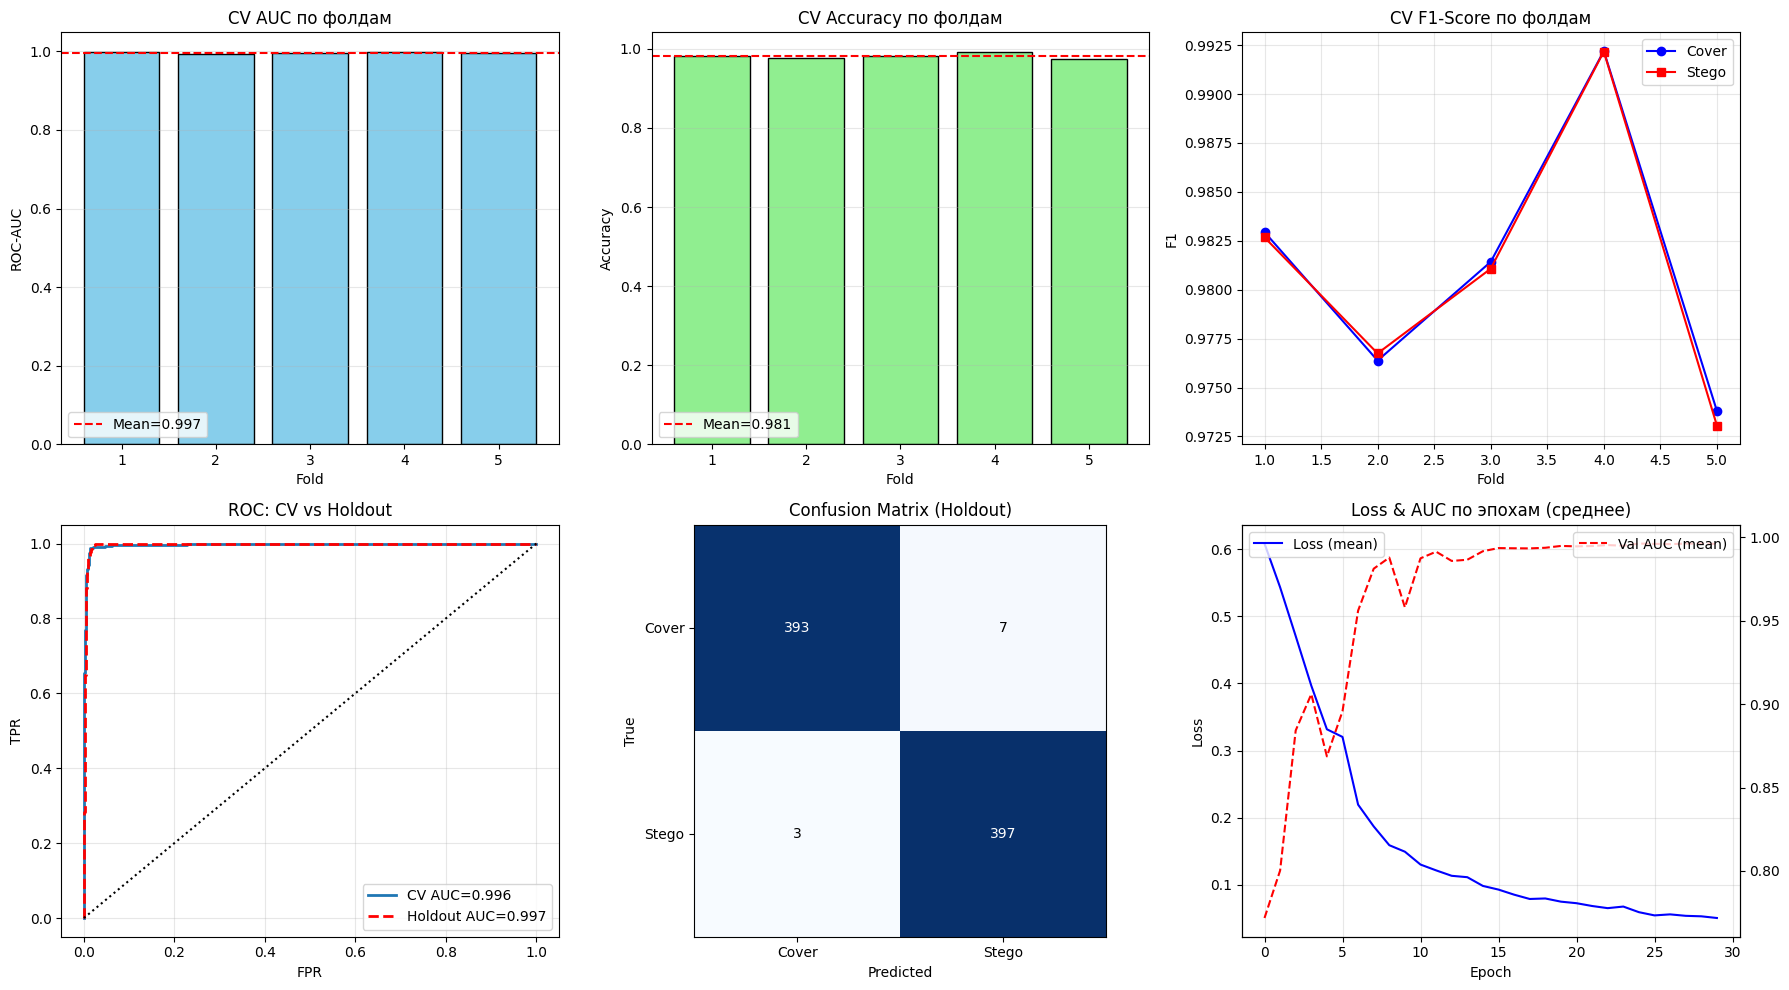


Результаты: /content/drive/MyDrive/FQW/yedroudj_results_2000_v06/yedroudj_v06_results.json


In [9]:
# 6. АГРЕГАЦИЯ CV + ФИНАЛЬНАЯ ОЦЕНКА НА HOLDOUT

print('\n' + '='*60)
print(' АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ 5-FOLD CV')
print('='*60)
for k in ['auc','accuracy','f1_cover','f1_stego',
          'precision_cover','precision_stego','recall_cover','recall_stego']:
    v = fold_metrics[k]
    print(f'{k.upper():<22s}: {np.mean(v):.4f} ± {np.std(v):.4f}  '
          f'[min={np.min(v):.4f}, max={np.max(v):.4f}]')

agg_l = np.array(all_fold_labels)
agg_p = np.array(all_fold_probs)
auc_rand = roc_auc_score(np.random.permutation(agg_l), agg_p)
print(f'\nAUC на случайных метках (проверка утечки): {auc_rand:.4f}  (должно быть ~0.50)')

fpr_a, tpr_a, thr_a = roc_curve(agg_l, agg_p)
thr_opt = float(thr_a[np.argmax(tpr_a - fpr_a)])
preds_agg = (agg_p > thr_opt).astype(int)
print(f'Оптимальный порог (агрегат): {thr_opt:.4f}')
print('\nClassification Report (CV агрегат):')
print(classification_report(agg_l, preds_agg, target_names=['Cover','Stego'], zero_division=0))

# ФИНАЛЬНАЯ ОЦЕНКА НА HOLDOUT TEST
print('\n' + '='*60)
print(' ФИНАЛЬНАЯ ОЦЕНКА НА HOLDOUT TEST SET (ранее невидимые данные)')
print('='*60)

# Берём лучшую модель по AUC среди фолдов
best_fold_idx = int(np.argmax(fold_metrics['auc']))
best_fold_path = os.path.join(SAVE_DIR, f'yedroudj_v06_fold_{best_fold_idx+1}.pth')
ckpt = torch.load(best_fold_path, weights_only=False)
best_model = YedroudjNetV06().to(device)
best_model.load_state_dict(ckpt['model_state_dict'])
best_model.eval()

test_dl = DataLoader(StegDataset(X_test, y_test, augment=False),
                     batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_probs, test_labels = [], []
with torch.no_grad():
    for imgs, blab in test_dl:
        probs = torch.sigmoid(best_model(imgs.to(device))).cpu().squeeze(1).numpy()
        test_probs.extend(probs.tolist())
        test_labels.extend(blab.numpy().tolist())

test_l = np.array(test_labels); test_p = np.array(test_probs)
test_auc = roc_auc_score(test_l, test_p)
fpr_t, tpr_t, thr_t = roc_curve(test_l, test_p)
test_thr = float(thr_t[np.argmax(tpr_t - fpr_t)])
test_preds = (test_p > test_thr).astype(int)
test_acc  = accuracy_score(test_l, test_preds)
test_f1s  = f1_score(test_l, test_preds, pos_label=1, zero_division=0)
test_f1c  = f1_score(test_l, test_preds, pos_label=0, zero_division=0)

print(f'Лучший фолд: {best_fold_idx+1} (CV AUC={fold_metrics["auc"][best_fold_idx]:.4f})')
print(f'Holdout AUC: {test_auc:.4f}')
print(f'Holdout Acc: {test_acc:.4f}')
print(f'F1-Cover:    {test_f1c:.4f}  |  F1-Stego: {test_f1s:.4f}')
print(f'Порог:       {test_thr:.4f}')
print('\nClassification Report (Holdout Test):')
print(classification_report(test_l, test_preds, target_names=['Cover','Stego'], zero_division=0))
cm_test = confusion_matrix(test_l, test_preds)
print('Confusion Matrix:'); print(cm_test)

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0,0].bar(range(1, N_FOLDS+1), fold_metrics['auc'], color='skyblue', edgecolor='k')
axes[0,0].axhline(np.mean(fold_metrics['auc']), color='red', linestyle='--',
                  label=f'Mean={np.mean(fold_metrics["auc"]):.3f}')
axes[0,0].set(xlabel='Fold', ylabel='ROC-AUC', title='CV AUC по фолдам')
axes[0,0].legend(); axes[0,0].grid(axis='y', alpha=0.3)

axes[0,1].bar(range(1, N_FOLDS+1), fold_metrics['accuracy'], color='lightgreen', edgecolor='k')
axes[0,1].axhline(np.mean(fold_metrics['accuracy']), color='red', linestyle='--',
                  label=f'Mean={np.mean(fold_metrics["accuracy"]):.3f}')
axes[0,1].set(xlabel='Fold', ylabel='Accuracy', title='CV Accuracy по фолдам')
axes[0,1].legend(); axes[0,1].grid(axis='y', alpha=0.3)

axes[0,2].plot(range(1,N_FOLDS+1), fold_metrics['f1_cover'], 'b-o', label='Cover')
axes[0,2].plot(range(1,N_FOLDS+1), fold_metrics['f1_stego'], 'r-s', label='Stego')
axes[0,2].set(xlabel='Fold', ylabel='F1', title='CV F1-Score по фолдам')
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

fpr_cv, tpr_cv, _ = roc_curve(agg_l, agg_p)
axes[1,0].plot(fpr_cv, tpr_cv, label=f'CV AUC={roc_auc_score(agg_l,agg_p):.3f}', lw=2)
axes[1,0].plot(fpr_t, tpr_t, 'r--', label=f'Holdout AUC={test_auc:.3f}', lw=2)
axes[1,0].plot([0,1],[0,1],'k:')
axes[1,0].set(xlabel='FPR', ylabel='TPR', title='ROC: CV vs Holdout')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

im = axes[1,1].imshow(cm_test, cmap='Blues')
axes[1,1].set(title='Confusion Matrix (Holdout)', xlabel='Predicted', ylabel='True')
axes[1,1].set_xticks([0,1]); axes[1,1].set_yticks([0,1])
axes[1,1].set_xticklabels(['Cover','Stego']); axes[1,1].set_yticklabels(['Cover','Stego'])
for i in range(2):
    for j in range(2):
        axes[1,1].text(j, i, str(cm_test[i,j]), ha='center', va='center',
                       color='white' if cm_test[i,j] > cm_test.max()/2 else 'black')

max_ep = max(len(h['loss']) for h in all_fold_histories)
mean_loss = [np.mean([h['loss'][e] for h in all_fold_histories if e<len(h['loss'])]) for e in range(max_ep)]
mean_auc  = [np.mean([h['val_auc'][e] for h in all_fold_histories if e<len(h['val_auc'])]) for e in range(max_ep)]
ax2 = axes[1,2].twinx()
axes[1,2].plot(mean_loss, 'b-',  label='Loss (mean)')
ax2.plot(mean_auc, 'r--', label='Val AUC (mean)')
axes[1,2].set(xlabel='Epoch', ylabel='Loss', title='Loss & AUC по эпохам (среднее)')
axes[1,2].legend(loc='upper left'); ax2.legend(loc='upper right')
axes[1,2].grid(alpha=0.3)

plt.tight_layout()
out_png = os.path.join(SAVE_DIR, 'yedroudj_v06_results.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()

# Сохранение
cv_results = {
    'version': 'V06',
    'hyperparameters': {'batch_size': BATCH_SIZE, 'lr': LR, 'epochs': EPOCHS,
                        'unfreeze_hpf': UNFREEZE_EPOCHS, 'patience': PATIENCE},
    'cv_metrics': {f'{k}_mean': float(np.mean(fold_metrics[k])) for k in fold_metrics} |
                  {f'{k}_std':  float(np.std(fold_metrics[k]))  for k in fold_metrics},
    'holdout': {'auc': float(test_auc), 'accuracy': float(test_acc),
                'f1_cover': float(test_f1c), 'f1_stego': float(test_f1s),
                'threshold': test_thr, 'confusion_matrix': cm_test.tolist()},
}
with open(os.path.join(SAVE_DIR, 'yedroudj_v06_results.json'), 'w') as f:
    json.dump(cv_results, f, indent=2)
print(f'\nРезультаты: {SAVE_DIR}/yedroudj_v06_results.json')
